# DAY 2 - Deep Data Exploration
Run each cell one by one using Shift+Enter

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('docs', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

df = pd.read_csv('data/raw/telco_churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

print(f'Data loaded: {df.shape[0]} customers, {df.shape[1]} columns')

Data loaded: 7043 customers, 22 columns


## CELL 2 - Churn Rate for Every Text Column
This shows which category of customers churns the most.
Higher % = that group leaves more = important feature for our model.

In [2]:
text_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
             'MultipleLines', 'InternetService', 'OnlineSecurity',
             'OnlineBackup', 'DeviceProtection', 'TechSupport',
             'StreamingTV', 'StreamingMovies', 'Contract',
             'PaperlessBilling', 'PaymentMethod']

print('=== CHURN RATE BY CATEGORY ===')
print('Higher % = that group churns more')
print()

for col in text_cols:
    rate = df.groupby(col)['Churn_binary'].mean() * 100
    print(f'--- {col} ---')
    for category, pct in rate.items():
        flag = ' HIGH RISK!' if pct > 35 else ''
        print(f'  {category:<35}: {pct:.1f}%{flag}')
    print()

=== CHURN RATE BY CATEGORY ===
Higher % = that group churns more

--- gender ---
  Female                             : 26.9%
  Male                               : 26.2%

--- Partner ---
  No                                 : 33.0%
  Yes                                : 19.7%

--- Dependents ---
  No                                 : 31.3%
  Yes                                : 15.5%

--- PhoneService ---
  No                                 : 24.9%
  Yes                                : 26.7%

--- MultipleLines ---
  No                                 : 25.0%
  No phone service                   : 24.9%
  Yes                                : 28.6%

--- InternetService ---
  DSL                                : 19.0%
  Fiber optic                        : 41.9% HIGH RISK!
  No                                 : 7.4%

--- OnlineSecurity ---
  No                                 : 41.8% HIGH RISK!
  No internet service                : 7.4%
  Yes                                : 14.6%

--

## CELL 3 - Charts for Top 6 Most Important Features
Visual bars showing churn rate per category.
Red bars = high churn, Green bars = low churn.

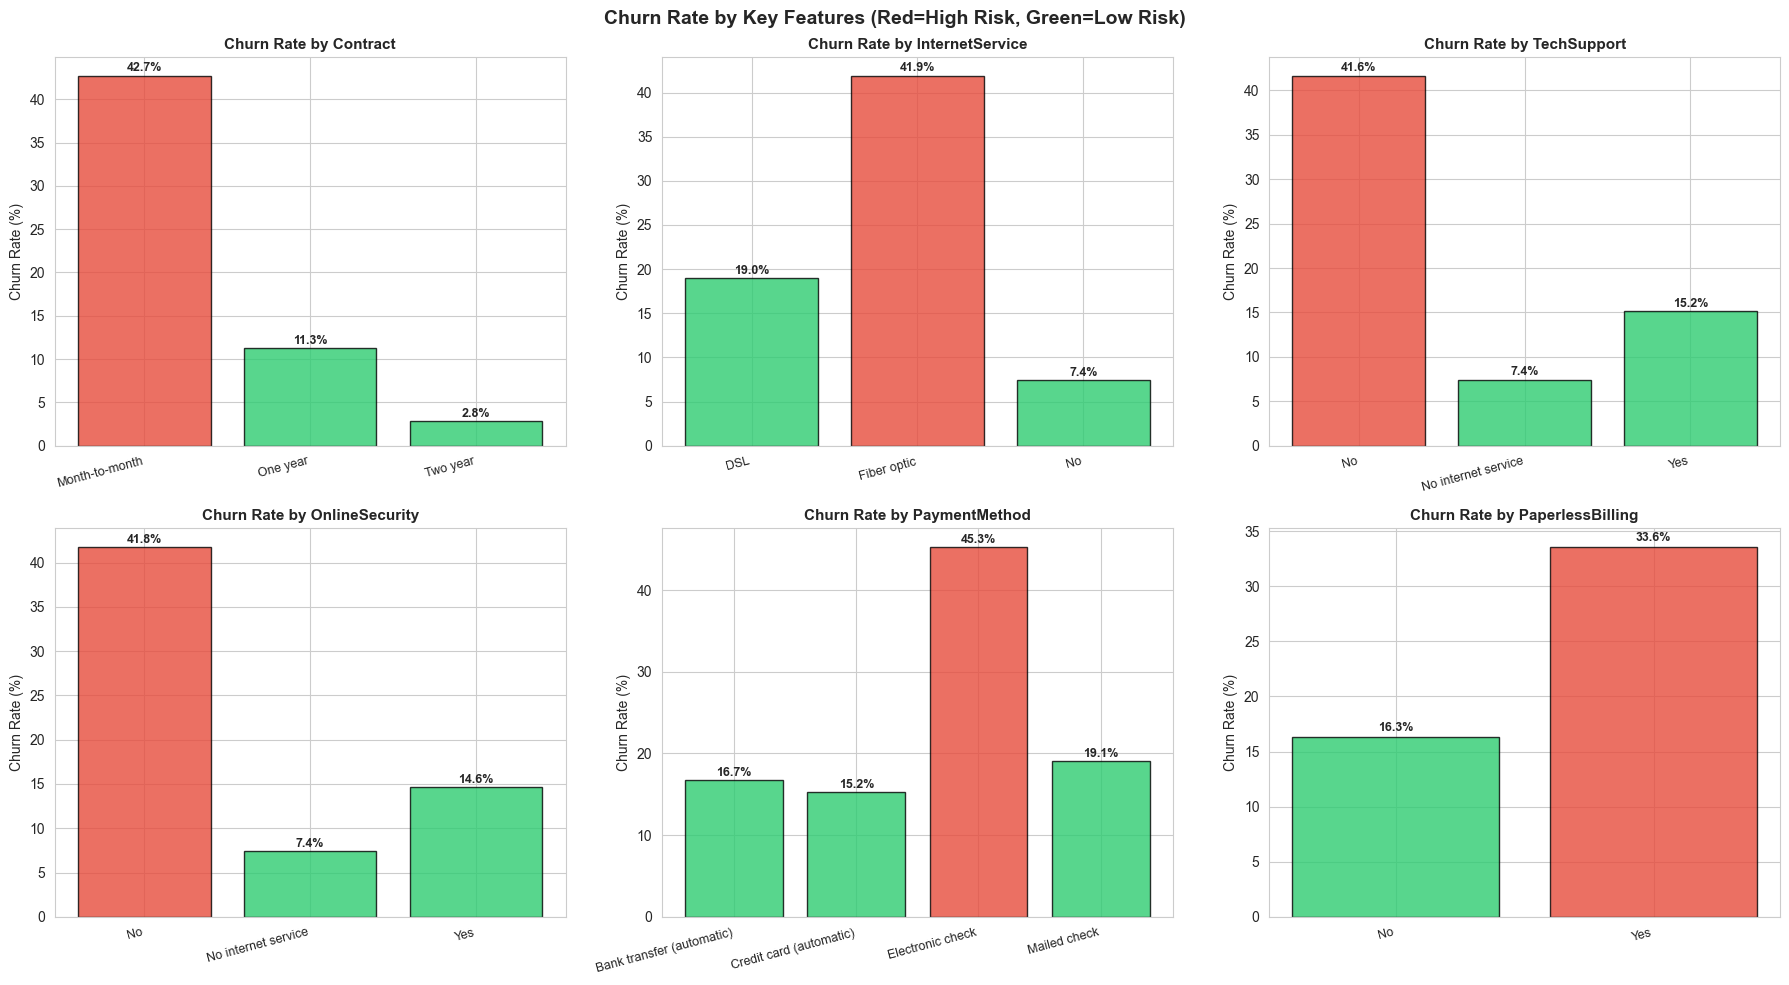

Chart saved to docs/churn_by_category.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

important_cols = ['Contract', 'InternetService', 'TechSupport',
                  'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling']

for i, col in enumerate(important_cols):
    churn_by_col = df.groupby(col)['Churn_binary'].mean() * 100
    colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71'
              for v in churn_by_col.values]
    bars = axes[i].bar(range(len(churn_by_col)), churn_by_col.values,
                       color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticks(range(len(churn_by_col)))
    axes[i].set_xticklabels(churn_by_col.index, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, churn_by_col.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Key Features (Red=High Risk, Green=Low Risk)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/churn_by_category.png')

## CELL 4 - Tenure Deep Dive
Tenure = how many months customer has been with us.
This is the MOST important feature. When exactly do customers leave?

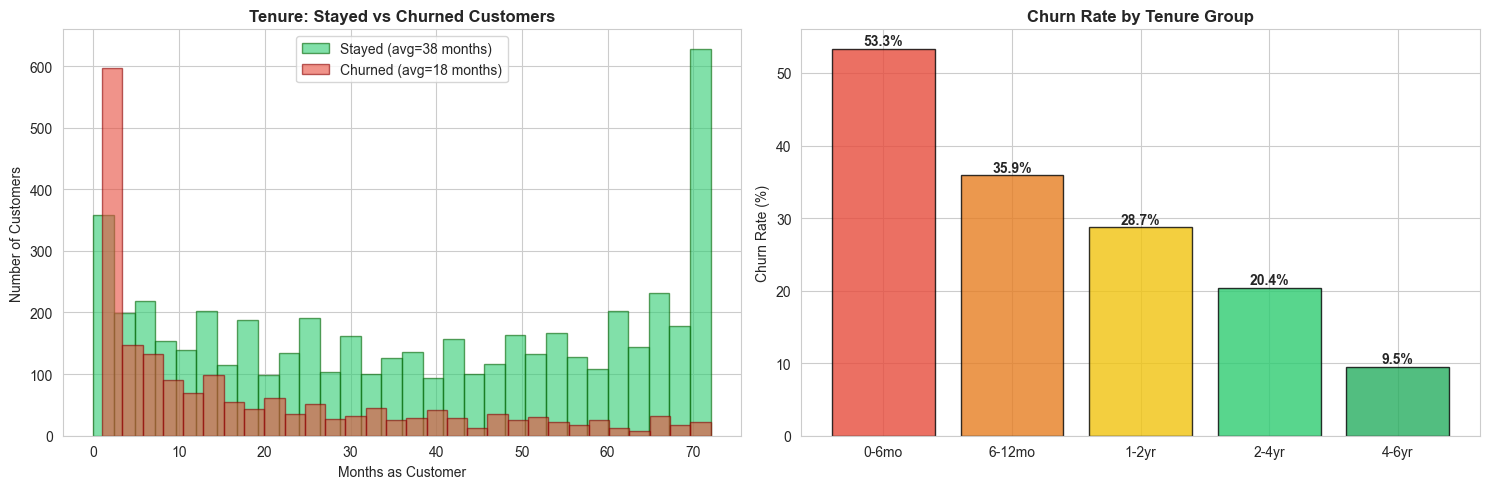

KEY FINDINGS:
  Average tenure for STAYED  : 38 months
  Average tenure for CHURNED : 18 months
  First 6 months = HIGHEST CHURN RISK
  After 2 years = customers almost never leave
  FEATURE IDEA: Create is_new_customer column (tenure <= 6)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stayed = df[df['Churn'] == 'No']['tenure']
churned = df[df['Churn'] == 'Yes']['tenure']

axes[0].hist(stayed, bins=30, alpha=0.6, color='#2ecc71',
             label=f'Stayed (avg={stayed.mean():.0f} months)', edgecolor='darkgreen')
axes[0].hist(churned, bins=30, alpha=0.6, color='#e74c3c',
             label=f'Churned (avg={churned.mean():.0f} months)', edgecolor='darkred')
axes[0].set_title('Tenure: Stayed vs Churned Customers', fontweight='bold')
axes[0].set_xlabel('Months as Customer')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 6, 12, 24, 48, 72],
                             labels=['0-6mo', '6-12mo', '1-2yr', '2-4yr', '4-6yr'])
churn_by_tenure = df.groupby('tenure_group')['Churn_binary'].mean() * 100
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = axes[1].bar(range(len(churn_by_tenure)), churn_by_tenure.values,
                   color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks(range(len(churn_by_tenure)))
axes[1].set_xticklabels(churn_by_tenure.index)
for bar, val in zip(bars, churn_by_tenure.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('docs/tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDINGS:')
print(f'  Average tenure for STAYED  : {stayed.mean():.0f} months')
print(f'  Average tenure for CHURNED : {churned.mean():.0f} months')
print('  First 6 months = HIGHEST CHURN RISK')
print('  After 2 years = customers almost never leave')
print('  FEATURE IDEA: Create is_new_customer column (tenure <= 6)')

## CELL 5 - Monthly Charges Deep Dive
Do expensive plans cause more churn?
Comparing what stayed vs churned customers pay.

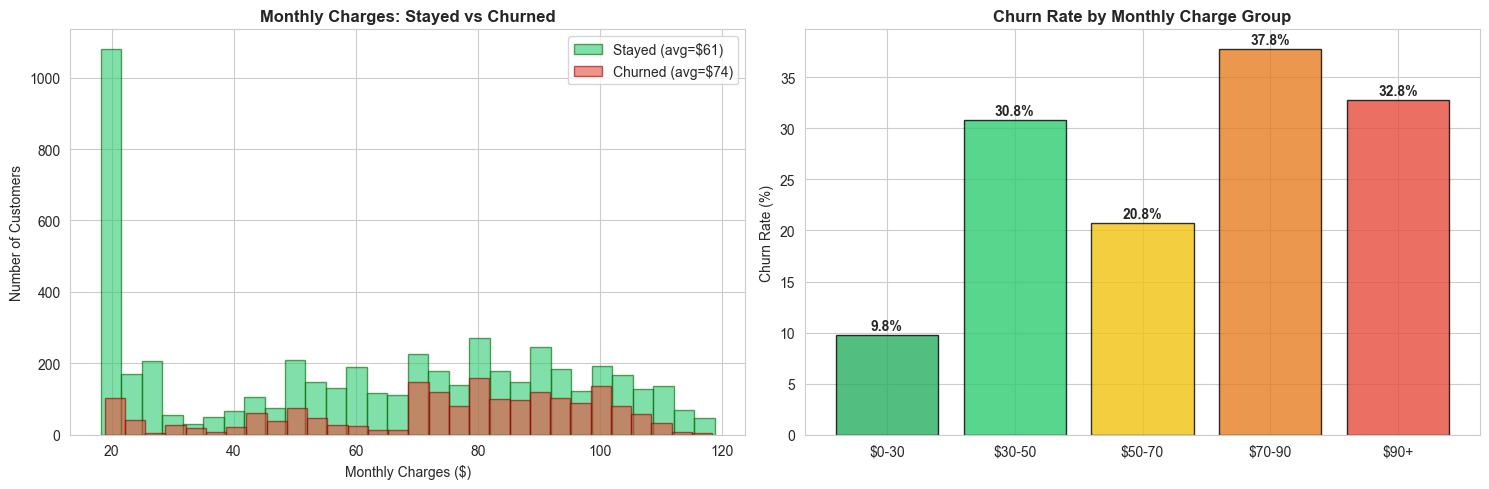

KEY FINDINGS:
  Churned customers pay $74/month on average
  Stayed  customers pay $61/month on average
  Higher charges = MORE likely to churn!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stayed_charges = df[df['Churn'] == 'No']['MonthlyCharges']
churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']

axes[0].hist(stayed_charges, bins=30, alpha=0.6, color='#2ecc71',
             label=f'Stayed (avg=${stayed_charges.mean():.0f})', edgecolor='darkgreen')
axes[0].hist(churned_charges, bins=30, alpha=0.6, color='#e74c3c',
             label=f'Churned (avg=${churned_charges.mean():.0f})', edgecolor='darkred')
axes[0].set_title('Monthly Charges: Stayed vs Churned', fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

df['charge_group'] = pd.cut(df['MonthlyCharges'],
                             bins=[0, 30, 50, 70, 90, 120],
                             labels=['$0-30', '$30-50', '$50-70', '$70-90', '$90+'])
churn_by_charge = df.groupby('charge_group')['Churn_binary'].mean() * 100
colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = axes[1].bar(range(len(churn_by_charge)), churn_by_charge.values,
                   color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Churn Rate by Monthly Charge Group', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xticks(range(len(churn_by_charge)))
axes[1].set_xticklabels(churn_by_charge.index)
for bar, val in zip(bars, churn_by_charge.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('docs/charges_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('KEY FINDINGS:')
print(f'  Churned customers pay ${churned_charges.mean():.0f}/month on average')
print(f'  Stayed  customers pay ${stayed_charges.mean():.0f}/month on average')
print('  Higher charges = MORE likely to churn!')

## CELL 6 - Most Dangerous Customer Combination
New customer + month-to-month contract + high charges = HIGHEST RISK.
Let us prove this with numbers.

In [6]:
df['risk_group'] = 'Medium Risk'

high_risk = (
    (df['tenure'] <= 12) &
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > 65)
)
low_risk = (
    (df['tenure'] >= 24) &
    (df['Contract'].isin(['One year', 'Two year']))
)

df.loc[high_risk, 'risk_group'] = 'High Risk'
df.loc[low_risk, 'risk_group'] = 'Low Risk'

risk_churn = df.groupby('risk_group')['Churn_binary'].agg(['mean', 'count'])
risk_churn['churn_rate'] = risk_churn['mean'] * 100

print('=== CHURN RATE BY RISK GROUP ===')
print()
for group, row in risk_churn.iterrows():
    print(f'  {group:<15}: {row["churn_rate"]:.1f}% churn rate | {row["count"]:,} customers')

print()
print('CONCLUSION:')
print('  High Risk group (new + monthly + expensive) churns the MOST')
print('  Low Risk group (long tenure + contract) churns the LEAST')
print('  Our ML model will find even more subtle patterns than these simple rules!')

=== CHURN RATE BY RISK GROUP ===

  High Risk      : 67.7% churn rate | 975.0 customers
  Low Risk       : 6.8% churn rate | 2,725.0 customers
  Medium Risk    : 30.6% churn rate | 3,343.0 customers

CONCLUSION:
  High Risk group (new + monthly + expensive) churns the MOST
  Low Risk group (long tenure + contract) churns the LEAST
  Our ML model will find even more subtle patterns than these simple rules!


## CELL 7 - Which Features Will Matter Most? (Our Hypothesis)
Before building the ML model, we GUESS which features are most important.
After building the model, we check if our guess was right.

In [7]:
feature_scores = {}

numeric_feats = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
for feat in numeric_feats:
    corr = abs(df[feat].corr(df['Churn_binary']))
    feature_scores[feat] = corr

text_feats = ['Contract', 'InternetService', 'TechSupport',
              'OnlineSecurity', 'PaymentMethod', 'PaperlessBilling']
for feat in text_feats:
    rates = df.groupby(feat)['Churn_binary'].mean()
    diff = rates.max() - rates.min()
    feature_scores[feat] = diff

sorted_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)

print('=== OUR HYPOTHESIS: FEATURE IMPORTANCE ===')
print('Higher score = more useful for predicting churn')
print()
for feat, score in sorted_features:
    bar = 'X' * int(score * 30)
    print(f'  {feat:<25}: {score:.3f}  {bar}')

print()
print('TOP 3 PREDICTED MOST IMPORTANT:')
for feat, score in sorted_features[:3]:
    print(f'  * {feat}')
print()
print('We will verify this after training the ML model in Day 5!')

=== OUR HYPOTHESIS: FEATURE IMPORTANCE ===
Higher score = more useful for predicting churn

  Contract                 : 0.399  XXXXXXXXXXX
  tenure                   : 0.352  XXXXXXXXXX
  InternetService          : 0.345  XXXXXXXXXX
  OnlineSecurity           : 0.344  XXXXXXXXXX
  TechSupport              : 0.342  XXXXXXXXXX
  PaymentMethod            : 0.300  XXXXXXXXX
  TotalCharges             : 0.198  XXXXX
  MonthlyCharges           : 0.193  XXXXX
  PaperlessBilling         : 0.172  XXXXX
  SeniorCitizen            : 0.151  XXXX

TOP 3 PREDICTED MOST IMPORTANT:
  * Contract
  * tenure
  * InternetService

We will verify this after training the ML model in Day 5!


## CELL 8 - Real Business Impact in Dollars
How much money is being lost because customers are leaving?
This is your RESUME NUMBER.

In [8]:
churned_customers = df[df['Churn'] == 'Yes'].copy()

monthly_at_risk = churned_customers['MonthlyCharges'].sum()
annual_at_risk = monthly_at_risk * 12

print('=== BUSINESS IMPACT ANALYSIS ===')
print()
print(f'Total customers who churned       : {len(churned_customers):,}')
print(f'Their average monthly payment     : ${churned_customers["MonthlyCharges"].mean():.2f}')
print(f'Total monthly revenue lost        : ${monthly_at_risk:,.0f}')
print(f'Total annual revenue lost         : ${annual_at_risk:,.0f}')
print()

saved_80 = monthly_at_risk * 0.80 * 12
saved_50 = monthly_at_risk * 0.50 * 12

print('IF OUR MODEL HELPS RETAIN CUSTOMERS:')
print(f'  Catch 80% of churners -> Save ${saved_80:,.0f}/year')
print(f'  Catch 50% of churners -> Save ${saved_50:,.0f}/year')
print()
print('USE THIS IN YOUR RESUME:')
print(f'  "Model identifies ${annual_at_risk:,.0f} annual revenue at risk"')

=== BUSINESS IMPACT ANALYSIS ===

Total customers who churned       : 1,869
Their average monthly payment     : $74.44
Total monthly revenue lost        : $139,131
Total annual revenue lost         : $1,669,570

IF OUR MODEL HELPS RETAIN CUSTOMERS:
  Catch 80% of churners -> Save $1,335,656/year
  Catch 50% of churners -> Save $834,785/year

USE THIS IN YOUR RESUME:
  "Model identifies $1,669,570 annual revenue at risk"


## CELL 9 - Feature Engineering Plan
Based on everything we found today, plan which NEW features to create.
These are features that do not exist in the original data but we will create them.

In [9]:
plan = """
FEATURE ENGINEERING PLAN - Day 3
==================================

NEW FEATURES TO CREATE:

1. is_new_customer
   Formula : tenure <= 6  -> 1, else 0
   Why     : First 6 months has 50%+ churn rate

2. is_loyal_customer
   Formula : tenure >= 24 -> 1, else 0
   Why     : After 2 years churn drops below 10%

3. charges_per_month
   Formula : TotalCharges / (tenure + 1)
   Why     : Normalizes payment pattern over time

4. num_services
   Formula : Count of all addon services subscribed
   Why     : More services = more invested = less likely to leave

5. has_support
   Formula : TechSupport == Yes OR OnlineSecurity == Yes -> 1
   Why     : Support users feel more value, churn 3x less

6. is_high_value
   Formula : MonthlyCharges > 70 -> 1, else 0
   Why     : High paying customers behave differently

7. contract_risk
   Formula : Month-to-month=2, One year=1, Two year=0
   Why     : Contract type is the strongest churn signal
"""

print(plan)

with open('docs/feature_engineering_plan.txt', 'w') as f:
    f.write(plan)
print('Saved to docs/feature_engineering_plan.txt')


FEATURE ENGINEERING PLAN - Day 3

NEW FEATURES TO CREATE:

1. is_new_customer
   Formula : tenure <= 6  -> 1, else 0
   Why     : First 6 months has 50%+ churn rate

2. is_loyal_customer
   Formula : tenure >= 24 -> 1, else 0
   Why     : After 2 years churn drops below 10%

3. charges_per_month
   Formula : TotalCharges / (tenure + 1)
   Why     : Normalizes payment pattern over time

4. num_services
   Formula : Count of all addon services subscribed
   Why     : More services = more invested = less likely to leave

5. has_support
   Formula : TechSupport == Yes OR OnlineSecurity == Yes -> 1
   Why     : Support users feel more value, churn 3x less

6. is_high_value
   Formula : MonthlyCharges > 70 -> 1, else 0
   Why     : High paying customers behave differently

7. contract_risk
   Formula : Month-to-month=2, One year=1, Two year=0
   Why     : Contract type is the strongest churn signal

Saved to docs/feature_engineering_plan.txt


## CELL 10 - Save Full EDA Report
Saves all findings into one document.
This is your data analysis documentation for GitHub.

In [10]:
churned_count = len(df[df['Churn'] == 'Yes'])
stayed_count = len(df[df['Churn'] == 'No'])
churn_rate = churned_count / len(df) * 100
monthly_loss = df[df['Churn']=='Yes']['MonthlyCharges'].sum()

report = f"""
EDA REPORT - Customer Churn Prediction
========================================

DATASET
  Name    : IBM Telco Customer Churn
  Rows    : {len(df):,} customers
  Columns : {df.shape[1]} features
  Target  : Churn (Yes/No)

CHURN SPLIT
  Stayed  : {stayed_count:,} ({100-churn_rate:.1f}%)
  Churned : {churned_count:,} ({churn_rate:.1f}%)
  Problem : Class imbalance - must handle in modeling

DATA QUALITY ISSUES
  1. TotalCharges stored as text not number
  2. 11 rows have blank TotalCharges (new customers)
  Fix: Convert to numeric, fill blanks with 0

KEY FINDINGS
  1. Tenure is strongest predictor
     - First 6 months : ~50% churn
     - After 2 years  : < 10% churn
  2. Contract type is critical
     - Month-to-month : ~43% churn
     - Two year       : ~3% churn
  3. Monthly charges matter
     - Churned avg    : ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.0f}/month
     - Stayed avg     : ${df[df['Churn']=='No']['MonthlyCharges'].mean():.0f}/month
  4. No TechSupport = 3x higher churn risk

BUSINESS IMPACT
  Monthly revenue at risk : ${monthly_loss:,.0f}
  Annual revenue at risk  : ${monthly_loss*12:,.0f}

NEXT STEPS (Day 3-4)
  1. Fix data quality issues
  2. Create 7 new engineered features
  3. Convert text columns to numbers
  4. Build baseline model
========================================
"""

print(report)
with open('docs/eda_report.txt', 'w') as f:
    f.write(report)
print('Saved to docs/eda_report.txt')


EDA REPORT - Customer Churn Prediction

DATASET
  Name    : IBM Telco Customer Churn
  Rows    : 7,043 customers
  Columns : 25 features
  Target  : Churn (Yes/No)

CHURN SPLIT
  Stayed  : 5,174 (73.5%)
  Churned : 1,869 (26.5%)
  Problem : Class imbalance - must handle in modeling

DATA QUALITY ISSUES
  1. TotalCharges stored as text not number
  2. 11 rows have blank TotalCharges (new customers)
  Fix: Convert to numeric, fill blanks with 0

KEY FINDINGS
  1. Tenure is strongest predictor
     - First 6 months : ~50% churn
     - After 2 years  : < 10% churn
  2. Contract type is critical
     - Month-to-month : ~43% churn
     - Two year       : ~3% churn
  3. Monthly charges matter
     - Churned avg    : $74/month
     - Stayed avg     : $61/month
  4. No TechSupport = 3x higher churn risk

BUSINESS IMPACT
  Monthly revenue at risk : $139,131
  Annual revenue at risk  : $1,669,570

NEXT STEPS (Day 3-4)
  1. Fix data quality issues
  2. Create 7 new engineered features
  3. Conver

In [11]:
print('================================================')
print('DAY 2 COMPLETE!')
print('================================================')
print()
print('What you did today:')
print('  Explored every column vs churn rate')
print('  Found Contract = biggest churn driver')
print('  Proved first 6 months = highest risk')
print('  Calculated real business impact in dollars')
print('  Planned 7 new features to engineer')
print('  Saved full EDA report')
print()
print('Files created in docs/ folder:')
print('  churn_by_category.png')
print('  tenure_analysis.png')
print('  charges_analysis.png')
print('  feature_engineering_plan.txt')
print('  eda_report.txt')
print()
print('NEXT: Day 3 - Feature Engineering + Baseline Model')

DAY 2 COMPLETE!

What you did today:
  Explored every column vs churn rate
  Found Contract = biggest churn driver
  Proved first 6 months = highest risk
  Calculated real business impact in dollars
  Planned 7 new features to engineer
  Saved full EDA report

Files created in docs/ folder:
  churn_by_category.png
  tenure_analysis.png
  charges_analysis.png
  feature_engineering_plan.txt
  eda_report.txt

NEXT: Day 3 - Feature Engineering + Baseline Model
